In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

In [2]:
def preprocess_data(data):
    df= data.copy()

    df['speed'] = df['Distance'] / (df['Moving Time'] / 3600)

    df['Activity Date']= pd.to_datetime(
        df['Activity Date'],
        format='%b %d, %Y, %I:%M:%S %p'
        )
    df['year']= df['Activity Date'].dt.year
    df['month']= df['Activity Date'].dt.month
    df['day']= df['Activity Date'].dt.day
    df['hour']= df['Activity Date'].dt.hour

    df.drop(columns=['Activity Date'], inplace= True)

    return df

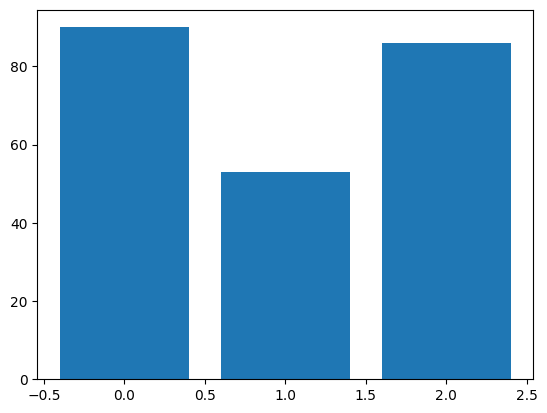

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le= LabelEncoder()

train_df= pd.read_csv("dataset_train.csv")

X= preprocess_data(train_df.drop(columns=['Activity ID', 'Label']))
y= le.fit_transform(train_df['Label'])

X_train, X_eval, y_train, y_eval= train_test_split(X, y, train_size=0.8, stratify=y, random_state= seed)

test_df= pd.read_csv("dataset_eval.csv")

X_test= preprocess_data(test_df.drop(columns=['Activity ID']))

plt.bar(np.unique_counts(y).values, np.unique_counts(y).counts)
plt.show()


In [4]:
# Subtask 1

monthMap = ("0","Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec")

answer1= pd.DataFrame([{
    'subtaskID': 1,
    'Answer1': monthMap[month],
    'Answer2': speed
} for month, speed in zip(range(1,13),X.groupby('month')['speed'].mean())])

answer1.head()

,subtaskID,Answer1,Answer2
0,1,Jan,14.453876
1,1,Feb,11.448271
2,1,Mar,12.993495
3,1,Apr,12.877157
4,1,May,12.645787


In [5]:
# Subtask 2

from catboost import CatBoostClassifier

model= CatBoostClassifier(
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    auto_class_weights='Balanced',
    random_state= seed,
    early_stopping_rounds= 200
)

model.fit(
    X_train, y_train,
    eval_set=[(X_eval, y_eval)],
    verbose=200
)

0:	learn: 1.0723680	test: 1.0722114	best: 1.0722114 (0)	total: 58.6ms	remaining: 2m 55s
200:	learn: 0.1519562	test: 0.2661118	best: 0.2661118 (200)	total: 428ms	remaining: 5.99s
400:	learn: 0.0567954	test: 0.1991186	best: 0.1990071 (399)	total: 731ms	remaining: 4.75s
600:	learn: 0.0337143	test: 0.1862567	best: 0.1857921 (595)	total: 973ms	remaining: 3.89s
800:	learn: 0.0230925	test: 0.1787522	best: 0.1787110 (796)	total: 1.23s	remaining: 3.4s
1000:	learn: 0.0176037	test: 0.1769306	best: 0.1766868 (980)	total: 1.46s	remaining: 2.92s
1200:	learn: 0.0140586	test: 0.1760072	best: 0.1758886 (1198)	total: 1.72s	remaining: 2.58s
1400:	learn: 0.0116383	test: 0.1751472	best: 0.1750810 (1395)	total: 2s	remaining: 2.29s
1600:	learn: 0.0098156	test: 0.1752212	best: 0.1749556 (1443)	total: 2.28s	remaining: 2s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.1749555984
bestIteration = 1443

Shrink model to first 1444 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=6, early_stopping_rounds=200, iterations=3000, learning_rate=0.03, random_state=42)

In [6]:
predictions= le.inverse_transform(model.predict(X_test).ravel())

answer2=pd.DataFrame([{
    'subtaskID': 2,
    'Answer1': id_,
    'Answer2': pred
} for id_, pred in zip(test_df['Activity ID'], predictions)])

answer2.head()

,subtaskID,Answer1,Answer2
0,2,14319106971,COMMUTE
1,2,12589508252,LEISURELY_COMMUTE
2,2,11908121839,COMMUTE
3,2,16687631914,PURE_LEISURE
4,2,12212251514,PURE_LEISURE


In [7]:
answer= pd.concat([answer1, answer2])
answer.to_csv("submission.csv", index= False)